# **Thermometry**

# Oxygen Isotope Thermometry: Opx-Cpx

## Fractionation Equation
The temperature-dependent oxygen isotope fractionation between Opx and Cpx is given by:

$$
\Delta^{18}\text{O}_{\text{Opx-Cpx}} = \delta^{18}\text{O}_{\text{Opx}} - \delta^{18}\text{O}_{\text{Cpx}}
$$

where:
- $\Delta^{18}\text{O}_{\text{Opx-Cpx}}$ is the fractionation (‰)
- $\delta^{18}\text{O}_{\text{Opx}}$ and $\delta^{18}\text{O}_{\text{Cpx}}$ are the isotope values of the minerals.

## Temperature Calibration
The fractionation factor $\alpha$ relates to temperature ($T$ in Kelvin):

$$
1000 \ln \alpha_{\text{Opx-Cpx}} = \frac{A \times 10^6}{T^2} + B
$$

### Common Calibrations:
1. **Matthews et al. (1983)**:
   $$
   1000 \ln \alpha_{\text{Opx-Cpx}} = \frac{1.88 \times 10^6}{T^2} - 3.13
   $$

2. **Chiba et al. (1989)** (recommended):
   $$
   1000 \ln \alpha_{\text{Opx-Cpx}} = \frac{1.57 \times 10^6}{T^2} - 0.53
   $$

## Solving for Temperature
Rearranging the Chiba et al. (1989) equation:

$$
T(K) = \sqrt{\frac{1.57 \times 10^6}{\Delta^{18}\text{O}_{\text{Opx-Cpx}} + 0.53}}
$$

Convert to °C:
$$
T(°C) = T(K) - 273.15
$$

## Example Calculation
Given:
- $\delta^{18}\text{O}_{\text{Opx}} = 5.6\ ‰$
- $\delta^{18}\text{O}_{\text{Cpx}} = 5.2\ ‰$

1. Calculate $\Delta^{18}\text{O}$:
   $$
   \Delta^{18}\text{O}_{\text{Opx-Cpx}} = 5.6 - 5.2 = 0.4\ ‰ 
   $$

2. Compute temperature (Chiba calibration):
   $$
   T(K) = \sqrt{\frac{1.57 \times 10^6}{0.4 + 0.53}} = \sqrt{1.688 \times 10^6} \approx 1298\ \text{K}
   $$

3. Convert to °C:
   $$
   T(°C) = 1298 - 273.15 \approx 1025°C
   $$

**Result**: Crystallization temperature ≈ **1025°C**.

In [3]:
import numpy as np

def calculate_opx_cpx_temp(d18O_opx: float, d18O_cpx: float, calibration: str = "Chiba") -> float:
    """
    Calculate crystallization temperature using Opx-Cpx δ¹⁸O fractionation.
    
    Parameters:
        d18O_opx (float): δ¹⁸O of orthopyroxene (‰).
        d18O_cpx (float): δ¹⁸O of clinopyroxene (‰).
        calibration (str): "Chiba" (default) or "Matthews".
    
    Returns:
        Temperature in °C.
    """
    delta = d18O_opx - d18O_cpx
    
    if calibration == "Chiba":
        A, B = 1.57e6, 0.53
    elif calibration == "Matthews":
        A, B = 1.88e6, 3.13
    else:
        raise ValueError("Calibration must be 'Chiba' or 'Matthews'.")
    
    T_kelvin = np.sqrt(A / (delta + B))
    T_celsius = T_kelvin - 273.15
    
    return T_celsius

In [4]:
# Example usage
d18O_opx = 6.621231   # ‰
d18O_cpx = 6.225780   # ‰
temp = calculate_opx_cpx_temp(d18O_opx, d18O_cpx, calibration="Chiba")
print(f"Calculated Temperature: {temp:.1f}°C")

Calculated Temperature: 1029.3°C


general thermometry (after chiba 1989)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [54]:
xx = np.linspace(0, 1.5, 10000)
xx = xx[1:]
T = xx*1e6

In [55]:
T

array([1.50015002e+02, 3.00030003e+02, 4.50045005e+02, ...,
       1.49969997e+06, 1.49984998e+06, 1.50000000e+06])

In [59]:
T_C = 1/((xx**0.5)/1e3) - 273.15
T_C

array([81372.4255078 , 57458.99009544, 46864.94499757, ...,
         543.428251  ,   543.3874129 ,   543.34658093])

In [60]:
def thermometry(A, B):
    return A*T + B

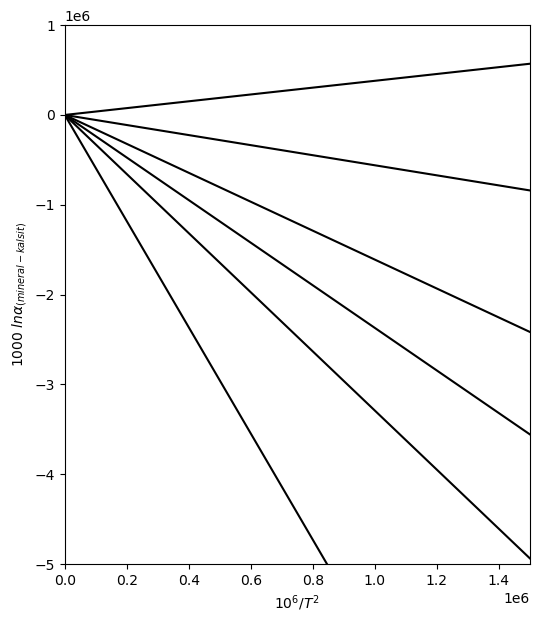

In [61]:
plt.figure(figsize=(6,7))
plt.plot(T, thermometry(0.38, 0), "k-")
plt.plot(T, thermometry(-0.56, 0), "k-")
plt.plot(T, thermometry(-1.61, 0), "k-")
plt.plot(T, thermometry(-2.37, 0), "k-")
plt.plot(T, thermometry(-3.29, 0), "k-")
plt.plot(T, thermometry(-5.91, 0), "k-")
plt.xlim(0,1.5*1e6), plt.ylim(-5*1e6,1*1e6)
#plt.xlim(0,1.5*1e6)
plt.xlabel(r'$10^{6}/T^2$'), plt.ylabel(r'$1000\ ln\alpha_{(mineral-kalsit)}$')
plt.show()

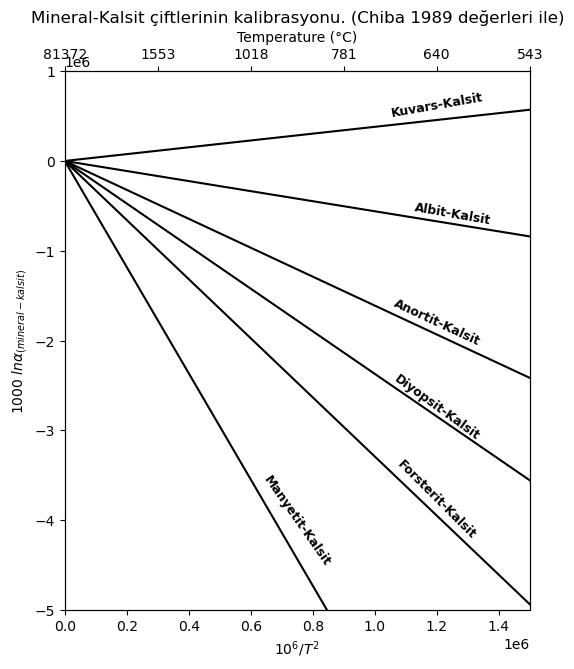

In [119]:
fig, ax1 = plt.subplots(figsize=(6, 7))

# Main plot
ax1.plot(T, thermometry(0.38, 0), "k-")
ax1.plot(T, thermometry(-0.56, 0), "k-")
ax1.plot(T, thermometry(-1.61, 0), "k-")
ax1.plot(T, thermometry(-2.37, 0), "k-")
ax1.plot(T, thermometry(-3.29, 0), "k-")
ax1.plot(T, thermometry(-5.91, 0), "k-")
ax1.set_xlim(0, 1.5 * 1e6)
ax1.set_ylim(-5 * 1e6, 1 * 1e6)
ax1.set_xlabel(r'$10^{6}/T^2$'), ax1.set_ylabel(r'$1000\ ln\alpha_{(mineral-kalsit)}$')

# Add text labels manually
ax1.text(1.2e6, 0.5*1e6, "Kuvars-Kalsit", rotation=10, fontsize=9, ha="center", weight="bold")
ax1.text(1.25e6, -0.7*1e6, "Albit-Kalsit", rotation=-10, fontsize=9, ha="center", weight="bold")
ax1.text(1.2e6, -2.05*1e6, "Anortit-Kalsit", rotation=-25, fontsize=9, ha="center", weight="bold")
ax1.text(1.2e6, -3.1*1e6, "Diyopsit-Kalsit", rotation=-36, fontsize=9, ha="center", weight="bold")
ax1.text(1.2e6, -4.2*1e6, "Forsterit-Kalsit", rotation=-45, fontsize=9, ha="center", weight="bold")
ax1.text(0.75e6, -4.5*1e6, "Manyetit-Kalsit", rotation=-55, fontsize=9, ha="center", weight="bold")


# Secondary x-axis (top) for temperature in Celsius
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())

# Select ticks to avoid overcrowding (e.g., every 2000th point)
tick_indices = np.linspace(0, len(T_C) - 1, 6, dtype=int)
ax2.set_xticks(T[tick_indices])
ax2.set_xticklabels([f"{tc:.0f}" for tc in T_C[tick_indices]])
ax2.set_xlabel("Temperature (°C)")


plt.title("Mineral-Kalsit çiftlerinin kalibrasyonu. (Chiba 1989 değerleri ile)")
plt.show()

C:\Users\altar\AppData\Local\Temp\ipykernel_13664\1182358594.py:39: RuntimeWarning: divide by zero encountered in divide
  return 1e6 / T**2


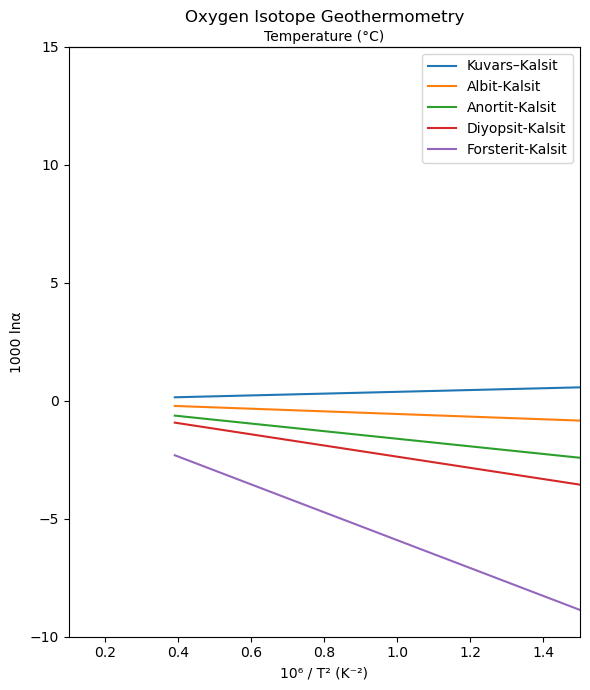

In [266]:
import numpy as np
import matplotlib.pyplot as plt

# Define temperature range (in Kelvin)
T = np.linspace(273.15, 1600, 1000)  # from 0°C to ~927°C

# Define geothermometry function
def ln_alpha(A, B, T):
    return A * 1e6 / T**2 + B

# Define mineral pairs with A and B values
mineral_pairs = {
    "Kuvars–Kalsit": (0.38, 0),
    "Albit-Kalsit": (-0.56, 0),
    "Anortit-Kalsit": (-1.61, 0),
    "Diyopsit-Kalsit": (-2.37, 0),
    "Forsterit-Kalsit": (-3.29, 0),
    "Forsterit-Kalsit": (-5.91, 0)
}

# Compute x-axis: 10⁶ / T²
x = 1e6 / T**2

# Plot
fig, ax = plt.subplots(figsize=(6, 7))

for label, (A, B) in mineral_pairs.items():
    y = ln_alpha(A, B, T)
    ax.plot(x, y, label=label)

ax.set_xlabel("10⁶ / T² (K⁻²)")
ax.set_ylabel("1000 lnα")
ax.set_title("Oxygen Isotope Geothermometry")
ax.set_xlim(0.1, 1.5), ax.set_ylim(-10, 15)
ax.legend()

# Add a secondary x-axis on top for Temperature (°C)
def T_to_x(T):
    return 1e6 / T**2

def x_to_T(x):
    return (1e6 / x)

secax = ax.secondary_xaxis('top', functions=(x_to_T, T_to_x))
secax.set_xlabel("Temperature (°C)")
secax.set_xticks([273.15, 373.15, 573.15, 773.15, 973.15, 1173.15])  # K
secax.set_xticklabels([f"{T - 273.15:.0f}" for T in secax.get_xticks()])  # Convert to °C

plt.tight_layout()
plt.show()
